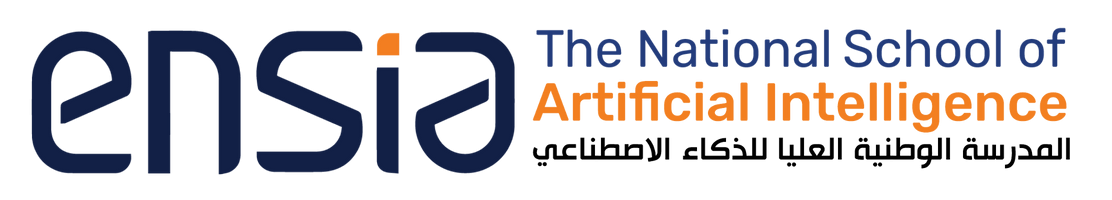

# **PROBABILITY BASED LEARNING___Part I: NAIVE BAYES**

# **Overview**
>Probability-based learning methods rely on the principles of probability theory to make predictions based on the **likelihood** of different outcomes. These models assume that the features of the data contribute **probabilistically** to the prediction of the target variable. One of the most widely used probability-based learning algorithms is the ***Naive Bayes Classifier***, known for its simplicity, efficiency, and effectiveness, especially with high-dimensional data.

> This lab notebook focuses on implementing and understanding two types of Naive Bayes classifiers:

1. Categorical Naive Bayes (CNB):
  - Designed for categorical features.
  - Estimates class-conditional probabilities based on the frequency of feature values in the training data.
  - Suitable for datasets with discrete variables.

2. Gaussian Naive Bayes (GNB):
  - Assumes that continuous features follow a Gaussian (normal) distribution.
  - Calculates class-conditional probabilities using the probability density function of the normal distribution.
  - Useful for datasets where features are continuous and approximately normally distributed.

3. Additionally, this notebook explores techniques for handling mixed-type features by combining the GNB and CNB approaches into a hybrid classifier. This classifier can be constructed using two different approaches:
  - **Direct Modeling**: Continuous features are modeled using Gaussian distributions, while categorical features are handled using frequency-based probabilities.
  - **Discretization Approach**: Continuous features are first transformed using equal-frequency binning, converting them into categorical features that can be processed using frequency-based probabilities.

## **Objectives**
By working through this notebook, you will gain practical insights into:

  - ✅ Calculating prior and likelihood probabilities.
  - ✅ Handling continuous and categorical data.
  - ✅ Implementing and validating Naive Bayes classifiers from scratch.

This hands-on approach will strengthen your understanding of probability-based models and their applications in real-world classification tasks. 🚀



---
# **PART I: Naive Bayes**
---

***Naive bayes***: is a supervied machine leaarning algorithm  that is used for classification tasks such as text classification. They use principles of probability to perform classification tasks.

Naïve Bayes is part of a family of generative learning algorithms, meaning that it seeks to model the distribution of inputs of a given class or category

Bayes’ Theorem is distinguished by its use of sequential events, where additional information later acquired impacts the initial probability. These probabilities are denoted as the prior probability and the posterior probability. The prior probability is the initial probability of an event before it is contextualized under a certain condition, or the marginal probability. The posterior probability is the probability of an event after observing a piece of data.

Naive Bayes classifier assumes that the effect of a particular feature in a class is independent of other features; the features are indepedent, this is what earned him the title of 'naive'.

**HOW NAIVE BAYES WORKS:**
Naive Bayes classifier calculates the probability of an event in the following steps:

  * **Step 1:**  Calculate the prior probability for given class labels
  * **Step 2:**  Find Likelihood probability with each attribute for each class
  * **Step 3:**  Put these value in Bayes Formula and calculate posterior probability.
  * **Step 4:**  Assign the class with the highest posterior probability to the input.
  

<img src="https://miro.medium.com/v2/resize:fit:828/format:webp/1*VGAoUgY28wygHsD-FXH4mg.jpeg" width="50%">


Naive Bayes Classifier formula can be written based on Bayes theorem as:

> $P(y \mid x_1, \ldots,x_j) = \frac{P(x_1,\ldots ,x_j \hspace{0.2cm} \mid \hspace{0.2cm} y) \hspace{0.2cm} P(y)}{P(x_1,\ldots,x_j)}$

Where,

- **$x_1,\ldots, x_j$** are j features that are independent of each other. y is the dependent variable.
- **$P(y \mid x_1,\ldots, x_j)$:** Posterior Probability
- **$P(x_1, \ldots, x_j \mid y)$:** Likelihood of features x1 to xj given that their class is y.
- **$P(y)$:** Prior Probability
- **$P(x_1,\ldots, x_j)$:** Marginal Probability

## **Implementation**

Before we jump into the main Naive bayes classes, let us first define some utility functions that we might need in some part of the upcoming sections

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt

from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.model_selection import train_test_split

## Utility Functions

> `accuracy_score`

In [2]:
def accuracy_score(y_true, y_pred):

	"""	score = (y_true - y_pred) / len(y_true) """

	return round(float(sum(y_pred == y_true))/float(len(y_true)) * 100 ,2)

---
## **1. NAIVE BAYES WITH DISCRETE FEATURES**
---
First let's try to implement the naive bayes with discrete features.

We will be using the Tennis Play dataset for training. This dataset includes **features [Outlook, Temperature, Humidity, Windy]**, and the corresponding **target** variable **'Play'** that corresponds to whether tennis is playable or not.

We need to predict whether players will play or not based on given weather conditions.

***
**Note**: For this first Variant of Naive Bayes Classifier, we will decompose the class methods into into smaller functions to simplify and clarify the workflow. After in a separate cell, we will merge everything in one single Class.
***

### Loading the data

array([[<Axes: title={'center': 'Temperature Numeric'}>,
        <Axes: title={'center': 'Humidity Numeric'}>]], dtype=object)

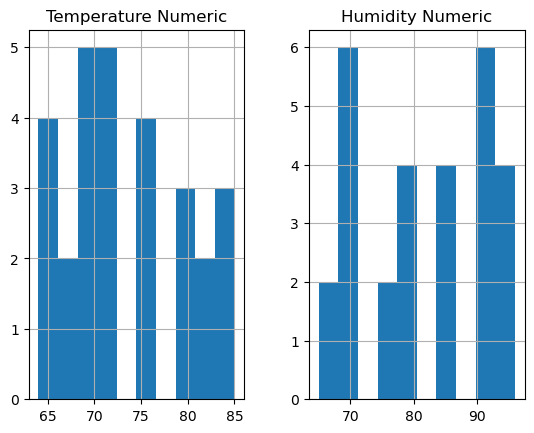

In [3]:
df = pd.read_csv('nb_data.csv')
df.shape
df.hist()

In [4]:
#df = pd.read_csv('nb_data.csv')
y = df['Play']
X = df.drop(columns=['Play', 'Temperature Numeric', 'Humidity Numeric'])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Training (Fitting) the model

The fit method estimates class priors and conditional probabilities for each feature value given a class, enabling the Naive Bayes Classifier to model the data distribution for prediction. It involves The first Two steps.

###  **Step 1:**  Calculate the prior probability for given class labels


First, we get the number of classes we have and the count of each class to detrimine the prior probabilities ($P(Y)$)

In [6]:
classes = []
priors = {}
classes, counts = np.unique(y_train, return_counts=True)
probabilities = counts / len(y_train)
priors = dict(zip(classes, probabilities))

print(f"the target classes are {classes}")
print(f'the prior probabilities are {priors}')

the target classes are ['no' 'yes']
the prior probabilities are {'no': np.float64(0.36363636363636365), 'yes': np.float64(0.6363636363636364)}


### **Step 2:** Find Likelihood probability with each attribute for each class

***How to compute the likelihoods ($P(x_1,\ldots ,x_j \hspace{0.2cm} \mid \hspace{0.2cm} y)$)💡:**
- Start by iterating through each target class and filtering the dataset to create a subset called **conditional_class**.
- Next, for each feature (attribute), calculate the likelihoods using the filtered data, referred to as **conditional_attr**, and store these values in our likelihood dictionary.

In [7]:
attributes= []
n_attributes = []
likelihoods = {}

attributes = list(X_train.columns)  # feature names
n_attributes = len(attributes)      # number of features

# Loop over each class to compute likelihood probabilities
for class_ in classes:
    likelihoods[class_] = {}  # Initialize an empty dictionary for this class
    conditional_class = X_train.loc[y_train == class_]  # rows in this class
    conditional_size = len(conditional_class)            # class sample count

    # Loop over each attribute to compute conditional probabilities
    for attr in attributes:
        conditional_attr = conditional_class.loc[:, attr]
        values, counts = np.unique(conditional_attr, return_counts=True)
        likelihoods[class_][attr] = dict(zip(values, counts / conditional_size))
likelihoods

{'no': {'Outlook': {'overcast': np.float64(0.125),
   'rainy': np.float64(0.375),
   'sunny': np.float64(0.5)},
  'Temperature Nominal': {'cool': np.float64(0.25),
   'hot': np.float64(0.625),
   'mild': np.float64(0.125)},
  'Humidity Nominal': {'high': np.float64(0.75), 'normal': np.float64(0.25)},
  'Windy': {np.False_: np.float64(0.25), np.True_: np.float64(0.75)}},
 'yes': {'Outlook': {'overcast': np.float64(0.35714285714285715),
   'rainy': np.float64(0.42857142857142855),
   'sunny': np.float64(0.21428571428571427)},
  'Temperature Nominal': {'cool': np.float64(0.2857142857142857),
   'hot': np.float64(0.14285714285714285),
   'mild': np.float64(0.5714285714285714)},
  'Humidity Nominal': {'high': np.float64(0.2857142857142857),
   'normal': np.float64(0.7142857142857143)},
  'Windy': {np.False_: np.float64(0.6428571428571429),
   np.True_: np.float64(0.35714285714285715)}}}

---
Now that we finished with Fitting the model, Let us explore how predictions are computed.
---

## Make Prediction (Predict)

> The predict method computes the posterior probability of each class for given instances using learned priors and likelihoods, returning the class with the highest probability. It invovles the third and forth steps,  

>Naive Bayes classifiers typically ***ignore the P(X)*** term (the denominator) when making predictions. This simplification is theoretically suboptimal but often leads to reasonable performance in practice.

> A naive Bayes model returns a **maximum a posteriori** (**MAP**) **prediction** where the posterior probabilities for the levels of the target feature are computed under the assumption of ***conditional independence*** between the descriptive features in an instance given a target feature level.

> Conditional independence between features allows  to **factorize** the *joint distribution*, and this helps with the ***curse of dimensionality problem*** by reducing the number of probabilities we are required to calculate from the data as well as the number of conditioning constraints on these probabilities



> $Class(q) =\overset{\small \textbf{argMax}}{\scriptsize _\text{c ∈ classes}} (\prod_{i=1}^{n} P(q_i \mid c)) \hspace{0.2cm} \text{x} \hspace{0.2cm} P(c) $


### **Step 3:** Put these value in Bayes Formula and calculate posterior probability.

> Fist, we get an unseen instance from the X_test set. So given the feature values ($x_1,\ldots,x_j$), we will try to predict whether or not we wil play tennis.

In [8]:
x = X_test.iloc[0 , :]
print(x)

Outlook                sunny
Temperature Nominal      hot
Humidity Nominal        high
Windy                  False
Name: 9, dtype: object


Then, we an empty dictionary where we store the probabilites of each class

In [9]:
predictions = {key : None for key in classes }
predictions

{'no': None, 'yes': None}

Everything is ready, Now we apply the formulas by multiplying the **likelihoods** by the **prior probabilities** to calculate the probability for each class.

In [10]:
# Loop over each class to compute the final probability
for class_ in classes:
    to_multiply = np.zeros(len(x) + 1)  # feature likelihoods + prior

    # Loop over each attribute and retrieve the corresponding likelihood probability
    for i, attr in enumerate(attributes):
        value = x[attr]  # value of this feature in the test sample
        to_multiply[i] = likelihoods[class_][attr][value]  # P(x_i | class)

    to_multiply[-1] = priors[class_]  # prior P(class)
    predictions[class_] = np.multiply.reduce(to_multiply)  # product of all terms

### **Step 4:** Assign the class with the highest posterior probability to the input.

In [11]:
print(predictions)
final_class = max(predictions, key=predictions.get)
final_class

{'no': np.float64(0.021306818181818184), 'yes': np.float64(0.0035780545984627618)}


'no'

---
> For this instance, we notice that naive bayes predicted **NO** as a Play class(It has higher score then 'Yes' Class).
---

## Now let's merge everything to a single class AND create our naive bayes classifier

In [12]:
class NaiveBayesClassifier:
    def __init__(self):
        self.priors = {}
        self.likelihoods = {}
        self.classes = []
        self.attributes = []
        self.alpha = 1.0
        self.attr_vocab = {}

    def fit(self, X: pd.DataFrame, y: np.ndarray):
        assert isinstance(X, pd.DataFrame), "X must be a pandas DataFrame."
        assert hasattr(y, "__len__"), "y must be array-like."
        assert len(X) == len(y), "X and y must have the same number of samples."

        self.classes, class_counts = np.unique(y, return_counts=True)
        self.priors = dict(zip(self.classes, class_counts / len(y)))
        self.attributes = list(X.columns)
        self.attr_vocab = {attr: np.unique(X[attr]) for attr in self.attributes}
        assert len(self.attributes) > 0, "X must have at least one feature."

        for class_ in self.classes:
            self.likelihoods[class_] = {}
            conditional_distribution = X.loc[y == class_]
            total = len(conditional_distribution)
            assert total > 0, f"No samples found for class {class_}."

            for attr in self.attributes:
                conditional_attr = conditional_distribution[attr]
                values, value_counts = np.unique(conditional_attr, return_counts=True)
                count_map = dict(zip(values, value_counts))
                V = len(self.attr_vocab[attr])

                # Laplace smoothing
                self.likelihoods[class_][attr] = {
                    v: (count_map.get(v, 0) + self.alpha) / (total + self.alpha * V)
                    for v in self.attr_vocab[attr]
                }

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            for attr in self.attributes:
                assert attr in X.columns, f"Missing attribute: {attr}"
            X = X[self.attributes].to_numpy()
        else:
            assert isinstance(X, np.ndarray), "X must be a pandas DataFrame or a numpy array."
            assert X.ndim == 2, "X must be a 2D array."
            assert X.shape[1] == len(self.attributes), "Mismatch in number of features between X and training data."

        return np.array([self.__predict(row) for row in X], dtype=object)

    def __predict(self, x):
        assert len(x) == len(self.attributes), "Input vector length does not match number of attributes."
        predictions = {}

        for class_ in self.classes:
            to_multiply = np.zeros(len(self.attributes) + 1)

            for i, attr in enumerate(self.attributes):
                value = x[i]
                V = len(self.attr_vocab[attr])
                fallback = self.alpha / (self.alpha * V + 1)  # small non-zero default
                to_multiply[i] = self.likelihoods[class_][attr].get(value, fallback)

            to_multiply[-1] = self.priors[class_]
            predictions[class_] = np.multiply.reduce(to_multiply)

        return max(predictions.items(), key=lambda pair: pair[1])[0]

In [13]:
clf = NaiveBayesClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_train)
score = accuracy_score(y_pred, y_train)
print(f"The predicted classes: {y_pred}")
print(f"With an accuracy of: {score}%")

The predicted classes: ['yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes'
 'yes' 'no' 'no' 'yes' 'no' 'yes' 'no' 'yes' 'no' 'yes']
With an accuracy of: 86.36%


---
> The Naive Bayes Classifier is ready!, Let's test it against Scikit-Learn's Categorical Naive Bayes classifier
---

In [14]:
# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Some Encoding (for the SKlearn Classifier)---------------------------
#-----------------------------------------------------------------------------------------------------------
for col in X.columns:
    X[col] = X[col].astype('category').cat.codes
# Convert target to numeric codes as well
y = y.astype('category').cat.codes
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Our Categorical Naive Bayes classifier-------------------------------
#-----------------------------------------------------------------------------------------------------------

clf = NaiveBayesClassifier()
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------scikit-learn Categorical Naive Bayes classifier----------------------
#-----------------------------------------------------------------------------------------------------------

gnb = CategoricalNB()
gnb.fit(X_tr, y_tr)
y_pred_sklearn = gnb.predict(X_te)

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Compare the results--------------------------------------------------
#-----------------------------------------------------------------------------------------------------------
print("Custom Categorical Naive Bayes predictions:", y_pred)
print("Scikit-learn Categorical Naive Bayes predictions:", y_pred_sklearn)

assert np.array_equal(y_pred, y_pred_sklearn), "The predictions do not match!"
print("Test passed successfully! =D, Congratulatiosn, your Classifier is working as expected.")

Custom Categorical Naive Bayes predictions: [np.int8(0) np.int8(1) np.int8(1) np.int8(1) np.int8(1) np.int8(1)]
Scikit-learn Categorical Naive Bayes predictions: [0 1 1 1 1 1]
Test passed successfully! =D, Congratulatiosn, your Classifier is working as expected.


---
## **2. NAIVE BAYES WITH CONTINUOUS FEATURES(GAUSSIAN NAIVE BAYES)**
---

>In the previous dataset, we had to drop continuous features to apply the Categorical Naive Bayes classifier. However, in real-world applications, this is rarely the best approach for classification problems. So, how can we effectively handle continuous features?

> In this section, we explore two common approaches:

> - ***Binning:*** A straightforward method that discretizes continuous features into bins, allowing them to be used with Categorical Naive Bayes.
- ***Probability Density Functions:*** A more robust approach that models continuous features using a probability distribution, enabling the computation of likelihoods directly.

### **2.1 Binning**

> First we load the same dataset, but this time we include all features

In [15]:
X = df.drop(['Play'], axis=1)
y = df['Play']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#### Extra Utility Functions

We need to define some utility functions that will assist in descritisizing our continuous features

> `equal_frequency_binning_fit`

In [16]:
def is_continuous(series, unique_threshold=10):
    """
    Heuristic check for continuous features:
    - numeric dtype
    - has enough distinct values
    """
    return pd.api.types.is_numeric_dtype(series) and series.nunique(dropna=True) >= unique_threshold

In [17]:
def equal_frequency_binning_fit(df, n_bins=4):
    """
    Fit equal-frequency binning on the DataFrame and return the bin edges for each numeric column.

    Parameters:
        df (pd.DataFrame): Input DataFrame with features.
        n_bins (int): Number of bins.

    Returns:
        dict: Dictionary mapping column names to bin edges.
    """
    bin_edges = {}
    for col in df.columns:
        if is_continuous(df[col]):
            # Compute quantiles and use them as bin edges
            quantiles = np.linspace(0, 100, n_bins + 1)
            edges = np.percentile(df[col].dropna(), quantiles)
            bin_edges[col] = edges
    return bin_edges

> `equal_frequency_binning_transform`

In [18]:
def equal_frequency_binning_transform(df, bin_edges):
    """
    Apply equal-frequency binning to the DataFrame using the provided bin edges.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        bin_edges (dict): Dictionary mapping column names to bin edges.

    Returns:
        pd.DataFrame: Transformed DataFrame with binned values as strings.
    """
    binned_df = df.copy()
    for col, edges in bin_edges.items():
        n_bins = len(edges) - 1
        labels = [f"bin{i+1}" for i in range(n_bins)]
        # Use pd.cut with fixed bin edges.
        # Setting include_lowest=True ensures the smallest value is included in the first bin.
        binned_df[col] = pd.cut(binned_df[col], bins=edges, include_lowest=True, labels=labels).astype(str)
    return binned_df

---
#### Discretizing continuous features (Binning)

> The first step in binning (equal frequency binning) is define foreach feature the bins boundaries or edges that defines each bin. Then the second step consists of using the boundaries to assign bins to instances according to their features values.

**Question:** Why do need the first step ? why not just assigning bins to instances without defining and storing boundaries ?

In [19]:
#-----------------------------Step 1-------------------------------------------
bin_edges = equal_frequency_binning_fit(X_train, n_bins=4)
#-----------------------------Step 2-------------------------------------------
X_train_binned = equal_frequency_binning_transform(X_train, bin_edges)
X_train_binned

,Outlook,Temperature Numeric,Temperature Nominal,Humidity Numeric,Humidity Nominal,Windy
17,rainy,bin3,mild,bin2,normal,False
22,sunny,bin1,cool,bin1,normal,False
11,sunny,bin2,mild,bin4,high,False
13,sunny,bin3,mild,bin1,normal,True
15,rainy,bin1,cool,bin2,normal,False
1,overcast,bin1,cool,bin1,normal,True
4,rainy,bin2,mild,bin4,high,False
5,rainy,bin1,cool,bin2,normal,False
2,overcast,bin2,mild,bin3,high,True
16,rainy,bin1,cool,bin1,normal,True


---
> #### Now, we got a set of categorical features that can be used by Our previous Categoical Naive Bayes Classifier.
---

In [20]:
clf2 = NaiveBayesClassifier()
clf2.fit(X_train_binned, y_train)
y_pred = clf2.predict(X_train_binned)
score = accuracy_score(y_pred, y_train)
print(f"The predicted classes: {y_pred}")
print(f"With an accuracy of: {score}%")

The predicted classes: ['yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes' 'yes'
 'yes' 'no' 'no' 'yes' 'no' 'yes' 'no' 'yes' 'no' 'yes']
With an accuracy of: 86.36%


> Now, Let us try to predict the classes for the X_test instances using `clf2` classifier

In [21]:
X_test_binned = equal_frequency_binning_transform(X_test, bin_edges)  # Discretize using TRAIN boundaries
y_pred = clf2.predict(X_test_binned)  # Predict on discretized test data
score = accuracy_score(y_pred, y_test)
print(f"The predicted classes: {y_pred}")
print(f"With an accuracy of: {score}%")

The predicted classes: ['no' 'yes' 'yes' 'yes' 'no' 'yes']
With an accuracy of: 50.0%


**🔶 You got an Error! Try to Figure out why.**  
Here’s a hint: check the likelihood of `'bin3'` for class `'No'`. What do you notice?  

<details>
  <summary>Click here to reveal the answer (Try to resolve it on you own) ✅</summary>

You guessed it right! ✅ The value `'bin3'` does not exist for class `'No'`, causing an error when attempting to retrieve its likelihood.  

Now, think of a way to modify the code to handle this scenario and prevent similar errors in future executions. 🚀

</details>

### 📌 **Homework 1: Fix the Zero Probability Problem with Laplace Smoothing**  

Currently, the Naïve Bayes classifier (with the discrete features) can assign **zero probabilities** when encountering unseen feature values in the test set. This can cause the entire probability for a class to become **zero**, leading to incorrect predictions.  

### 🛠️ Your Task:
Modify the likelihood calculation in the `fit` method to **apply Laplace smoothing**.  

### 🔢 Laplace Smoothing Formula:
$$P(x | C) = \frac{\text{count of } x \text{ in class } C + \alpha}{\text{total count of attributes in class } C + \alpha \cdot V}$$

Where:  
- \( x \) = feature value  
- \( C \) = class label  
- \( $\alpha$ \) (alpha) = smoothing parameter (commonly 1)  
- \( V \) = number of unique values for the feature  

### ✏️ Instructions:
1. Modify the likelihood computation in `fit` so that probabilities never become zero.  
2. Use ( $\alpha$ = 1 ) for smoothing.  
3. If a value was never seen in training, assign it a small probability instead of 0.  

### ✅ Once implemented, test the model on new unseen data! 🚀  


In [22]:
print(clf2.likelihoods['no']['Temperature Numeric'])   # if labels are strings
new_unseen = pd.DataFrame([{
    'Outlook': 'sunny',
    'Temperature Numeric': 'bin3',
    'Temperature Nominal': 'mild',
    'Humidity Numeric': 'bin4',
    'Humidity Nominal': 'high',
    'Windy': True
}])

pred_new = clf2.predict(new_unseen)
print("Prediction for unseen sample:", pred_new)

{'bin1': np.float64(0.25), 'bin2': np.float64(0.25), 'bin3': 0.08333333333333333, 'bin4': np.float64(0.4166666666666667)}
Prediction for unseen sample: ['yes']


In [23]:
new_unseen2 = pd.DataFrame([{
    'Outlook': 'stormy',   # unseen category
    'Temperature Numeric': 'bin9',  # unseen bin
    'Temperature Nominal': 'hot',
    'Humidity Numeric': 'bin2',
    'Humidity Nominal': 'normal',
    'Windy': False
}])

print(clf2.predict(new_unseen2))

['yes']


### **2.2 Probability Density Functions**

> A continuous feature can have an infinite number of values in its domain, so any particular value will occur a negligible amount of the time.


> **A probability density function (PDF)** represents the probability distribution of a continuous feature using a ***mathematical function***, and there are a large number of standard, well-defined probability distributions such as :
- ***Normal Distribution***  
- ***Exponential Distribution***
-  ***Mixture of Gaussians Distribution***

>In order to define a **probability density function (PDF)**, we must:

> * Select which **probability** distribution we believe will best model the distribution of the values of the feature by creating a density ***histogram*** of the feature’s values and compare the shape of this histogram to the shapes of the standard distributions. Choose the best that matches the shape of the histogram to model the feature.

> * **Fit the parameters** of the selected distribution to the feature values in the dataset



> To make the decision about the distribution to use:
  -  ***partition*** the training data based on the target feature
  -  ***generate histograms*** of the values of the descriptive feature for each of the splits.
  - We then ***select the statistical distribution*** that is most similar in shape to each of the resulting histograms.


#### Extra Imports

In [24]:
from math import sqrt
from math import exp
from math import pi
import matplotlib.pyplot as plt
from scipy import stats

#### Extra Utility Functions


In [25]:
# Define a function to plot the distribution and fitted curves
def plot_distributions(dataset):
  # Plot the distribution for each feature
  for feature_name in dataset.columns:

    if feature_name != 'target' and is_continuous(dataset[feature_name]):  # Skip target variable if present
      # plot_distribution(feature_name, dataset)
      # Extract the feature data
      feature_data = dataset[feature_name]

      # Try fitting a normal distribution
      norm_params = stats.norm.fit(feature_data)
      norm_dist = stats.norm(*norm_params)

      # Try fitting an exponential distribution
      exp_params = stats.expon.fit(feature_data)
      exp_dist = stats.expon(*exp_params)

      # Generate bins for the histogram
      bins = plt.hist(feature_data, density=True)[1]

      # Plot the histogram
      plt.plot(bins, norm_dist.pdf(bins), label='Normal Distribution')
      plt.plot(bins, exp_dist.pdf(bins), label='Exponential Distribution')
      plt.hist(feature_data, density=True, alpha=0.3)  # Semi-transparent histogram

      # Set labels and title
      plt.xlabel(feature_name)
      plt.ylabel('Density')
      plt.title(f'Distribution of {feature_name}')
      plt.legend()
      plt.grid(True)
      plt.show()

#### **___Iris Flower Species Dataset**

> In this section we will use the Iris Flower Species Dataset.
The Iris Flower Dataset involves predicting the flower species given measurements of iris flowers.

> It is a multiclass classification problem. The number of observations for each class is balanced. There are ***150 observations*** with ***4 input*** variables and ***1 output*** variable. The variable names are as follows:

- Sepal length in cm.
- Sepal width in cm.
- Petal length in cm.
- Petal width in cm.
- target


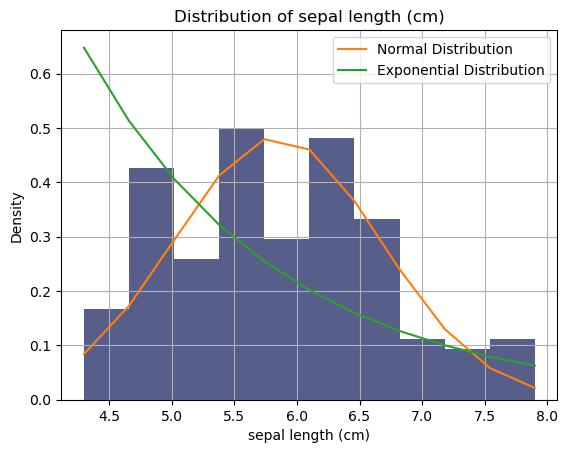

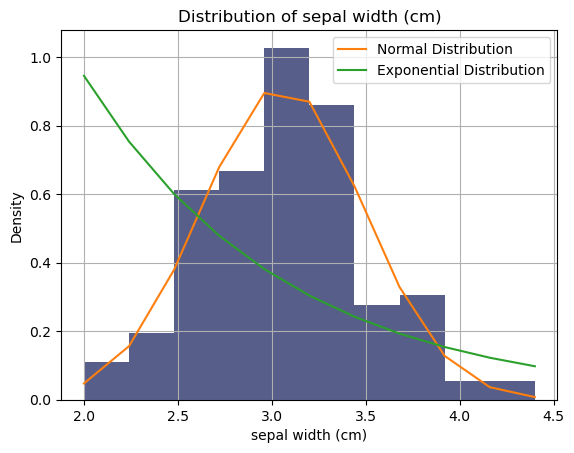

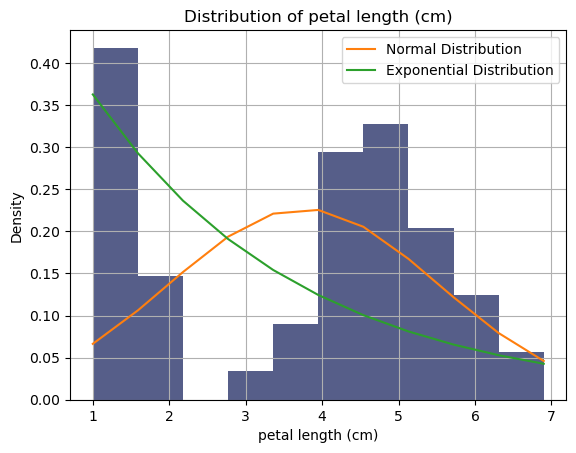

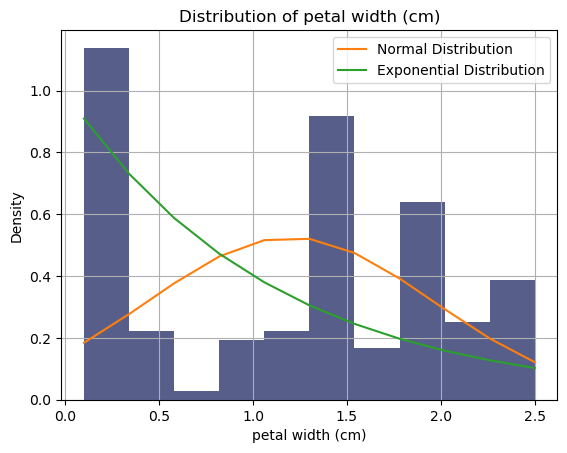

In [26]:
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

plot_distributions(X_iris)

X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)


> We notice that all features follow a normal distribution (it is not always the case in real world applications).

#### **Workflow:**
> **Gaussian Naive Bayes** classifier calculates the probability of an event in the following steps:

- **Step1:** *Compute Prior Probabilities* of each class in the dataset.
- **Step2:** *Estimate Likelihoods For each continuous feature*, estimate the mean and standard deviation per class, assuming a Gaussian distribution (for this lab).
- **Step3:** *Apply Gaussian Probability Density Function*, which consistes of Computing the likelihood of feature values given a class using the Gaussian formula.
- **Step4:** *Calculate Posterior Probabilities* by Multiply the likelihoods with the prior probabilities and assign the class with the highest probability.

In [27]:
class GaussianNaiveBayesClassifier:
    def __init__(self):
        self.priors = {}
        self.likelihoods = {}
        self.classes = []
        self.attributes = []
        self.n_attributes = 0

    def fit(self, X, y):
        assert isinstance(X, pd.DataFrame), "X must be a pandas DataFrame."
        assert hasattr(y, '__len__'), "y must be an array-like object."
        assert len(X) == len(y), "Number of samples in X and y must be equal."

        self.classes, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        self.priors = dict(zip(self.classes, probabilities))
        self.attributes = list(X.columns)
        self.n_attributes = len(self.attributes)

        assert self.n_attributes > 0, "X must have at least one feature."

        for class_ in self.classes:
            self.likelihoods[class_] = {}
            conditional_distribution = X.loc[y == class_]
            assert len(conditional_distribution) > 0, f"No samples found for class {class_}."

            means = conditional_distribution.mean(axis=0).to_numpy()
            stds = conditional_distribution.std(axis=0, ddof=0).to_numpy()

            assert means.shape[0] == self.n_attributes, "Mismatch in number of attributes for means."
            assert stds.shape[0] == self.n_attributes, "Mismatch in number of attributes for stds."

            self.likelihoods[class_]["means"] = means
            self.likelihoods[class_]["stds"] = stds

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            for attr in self.attributes:
                assert attr in X.columns, f"Missing attribute: {attr}"
            X = X[self.attributes].to_numpy()
        else:
            assert isinstance(X, np.ndarray), "X must be a pandas DataFrame or a numpy array."
            assert X.ndim == 2, "X must be a 2D array."
            assert X.shape[1] == self.n_attributes, "Number of features in X must match training data."

        return np.apply_along_axis(self.__predict, axis=1, arr=X)

    def __predict(self, x):
        assert len(x) == self.n_attributes, "Input vector length does not match number of attributes."
        predictions = {class_: None for class_ in self.classes}

        for class_ in self.classes:
            probabilities = self.__fill_probabilities(x, class_)
            predictions[class_] = np.multiply.reduce(probabilities)

        return max(predictions.items(), key=lambda pair: pair[1])[0]

    def __fill_probabilities(self, x, class_):
        probabilities = np.zeros(self.n_attributes + 1)

        assert class_ in self.priors, f"Prior for class {class_} not found."
        probabilities[-1] = self.priors[class_]

        means, stds = self.likelihoods[class_]["means"], self.likelihoods[class_]["stds"]
        stds = stds + 1e-9  # numerical stability

        assert means.shape[0] == len(x), "Mismatch between means and input vector length."
        assert stds.shape[0] == len(x), "Mismatch between stds and input vector length."

        probabilities[:-1] = self.__gaussian_fn(x, means, stds)
        return probabilities

    def __gaussian_fn(self, x, means, stds):
        x = np.asarray(x, dtype=float)
        means = np.asarray(means, dtype=float)
        stds = np.asarray(stds, dtype=float)

        assert x.shape == means.shape == stds.shape, "x, means, and stds must have the same shape."
        return (1 / (stds * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x - means) ** 2 / (stds ** 2))

---
> The Gaussian Naive Bayes classifier is ready! Let’s test it against scikit-learn’s implementation to see how it performs
---

In [28]:

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Our Gaussian Naive Bayes classifier----------------------------------
#-----------------------------------------------------------------------------------------------------------

clf = GaussianNaiveBayesClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------scikit-learn Gaussian Naive Bayes classifier-------------------------
#-----------------------------------------------------------------------------------------------------------

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_sklearn = gnb.predict(X_test)

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Compare the results--------------------------------------------------
#-----------------------------------------------------------------------------------------------------------
print("Custom GNB predictions:", y_pred)
print("Scikit-learn GNB predictions:", y_pred_sklearn)

assert np.array_equal(y_pred, y_pred_sklearn), "The predictions do not match!"
print("Test passed successfully! =D, Custom GNB predictions match scikit-learn GNB predictions.")

Custom GNB predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Scikit-learn GNB predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Test passed successfully! =D, Custom GNB predictions match scikit-learn GNB predictions.
